# GatedFusion Weight Analysis


## Setup


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
RUN_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'runs', 'protected', 'k_fold_CV'))

SEED_EXPERIMENTS = {
    1: '(final)20260413-071956__ctmp_gin__bs=1024__lr=6.10e-04__seed=1__cv=5__test=0.15',
    2: '(final)20260413-021503__ctmp_gin__bs=1024__lr=6.10e-04__seed=2__cv=5__test=0.15',
    3: '(final)20260413-021516__ctmp_gin__bs=1024__lr=6.10e-04__seed=3__cv=5__test=0.15',
}

COMPONENTS  = ['w_ad', 'w_dis', 'w_merged']
COMP_LABELS = ['Admission (w_ad)', 'Discharge (w_dis)', 'Merged (w_merged)']
COMP_COLORS = ['#3498db', '#e74c3c', '#2ecc71']
SEED_COLORS = ['#3498db', '#e74c3c', '#2ecc71']


In [3]:
dfs = {}
for seed, exp in SEED_EXPERIMENTS.items():
    path = os.path.join(RUN_DIR, exp, f'gated_fusion_w_los_kfold_seed{seed}.csv')
    dfs[seed] = pd.read_csv(path)

dfs[1].head()


,LOS,w_ad_mean,w_ad_std,n_samples,w_dis_mean,w_dis_std,w_merged_mean,w_merged_std
0,1,0.179841,0.252143,169605,0.271026,0.291353,0.549133,0.362911
1,2,0.103427,0.179180,43600,0.203466,0.245932,0.693107,0.307093
2,3,0.111693,0.174322,36615,0.215755,0.232604,0.672553,0.292895
3,4,0.104147,0.154675,32910,0.217910,0.219335,0.677943,0.274128
4,5,0.109590,0.156618,33585,0.216694,0.208152,0.673716,0.266596


## Visualisation

세 가지 시각화를 제공합니다.
- **Version 1** — Seed 1/2/3 overlaid: LOS별 패턴이 seed 간에 일관한지 확인
- **Version 2** — Combined (mean ± std across seeds): 최종 robust 시각화
- **Version 3** — Stacked bar: LOS별 gate weight 비율 구성


### Version 1 — 3 Seeds Overlaid


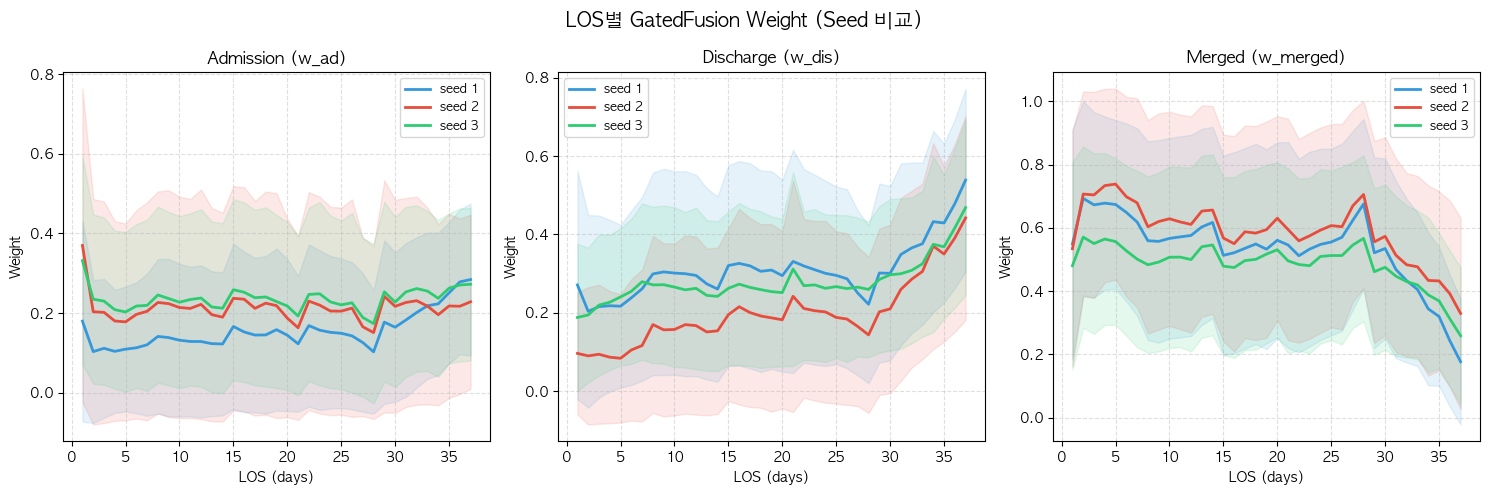

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('LOS별 GatedFusion Weight (Seed 비교)', fontsize=14, fontweight='bold')

for ax, comp, label in zip(axes, COMPONENTS, COMP_LABELS):
    for seed, color in zip([1, 2, 3], SEED_COLORS):
        df = dfs[seed]
        ax.plot(df['LOS'], df[f'{comp}_mean'], color=color, linewidth=2, label=f'seed {seed}')
        ax.fill_between(
            df['LOS'],
            df[f'{comp}_mean'] - df[f'{comp}_std'],
            df[f'{comp}_mean'] + df[f'{comp}_std'],
            color=color, alpha=0.12,
        )
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('LOS (days)')
    ax.set_ylabel('Weight')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('gated_fusion_weight_by_los_seeds_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()


### Version 2 — Combined (mean ± std across seeds)


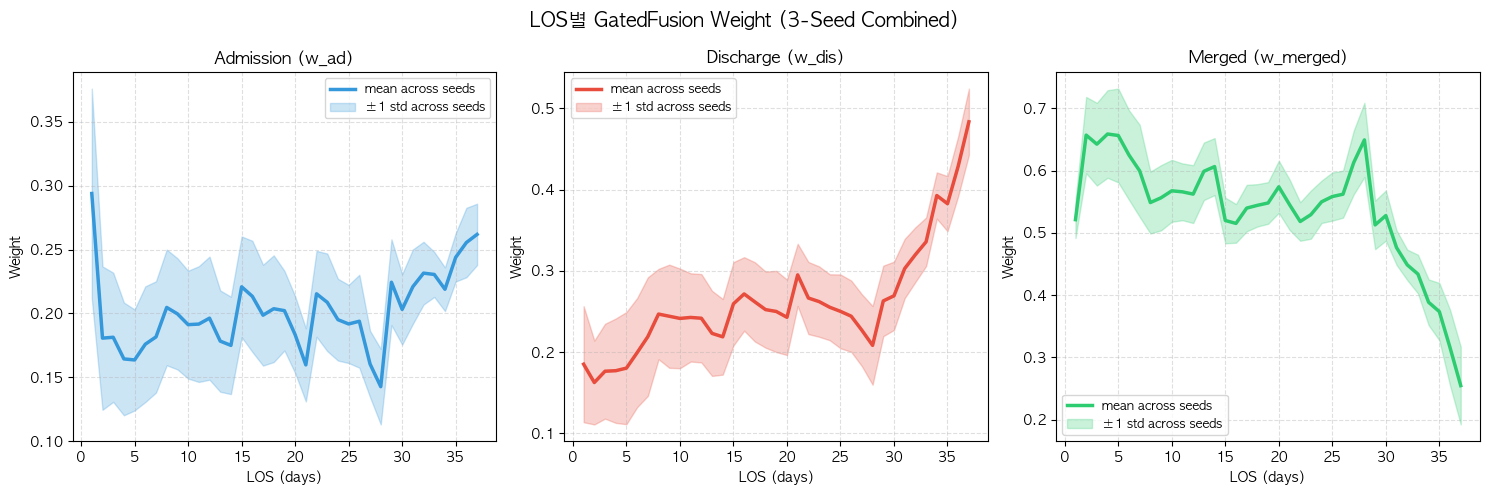

In [5]:
combined = dfs[1][['LOS', 'n_samples']].copy()
for comp in COMPONENTS:
    seed_means = np.stack([dfs[s][f'{comp}_mean'].values for s in [1, 2, 3]], axis=0)  # (3, 37)
    combined[f'{comp}_mean_across'] = seed_means.mean(axis=0)
    combined[f'{comp}_std_across']  = seed_means.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('LOS별 GatedFusion Weight (3-Seed Combined)', fontsize=14, fontweight='bold')

for ax, comp, label, color in zip(axes, COMPONENTS, COMP_LABELS, COMP_COLORS):
    mu  = combined[f'{comp}_mean_across']
    sig = combined[f'{comp}_std_across']
    los = combined['LOS']
    ax.plot(los, mu, color=color, linewidth=2.5, label='mean across seeds')
    ax.fill_between(los, mu - sig, mu + sig, color=color, alpha=0.25, label='±1 std across seeds')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('LOS (days)')
    ax.set_ylabel('Weight')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('gated_fusion_weight_by_los_combined.png', dpi=150, bbox_inches='tight')
plt.show()


### Version 3 — LOS별 Gate Weight 비율 (Stacked Bar)


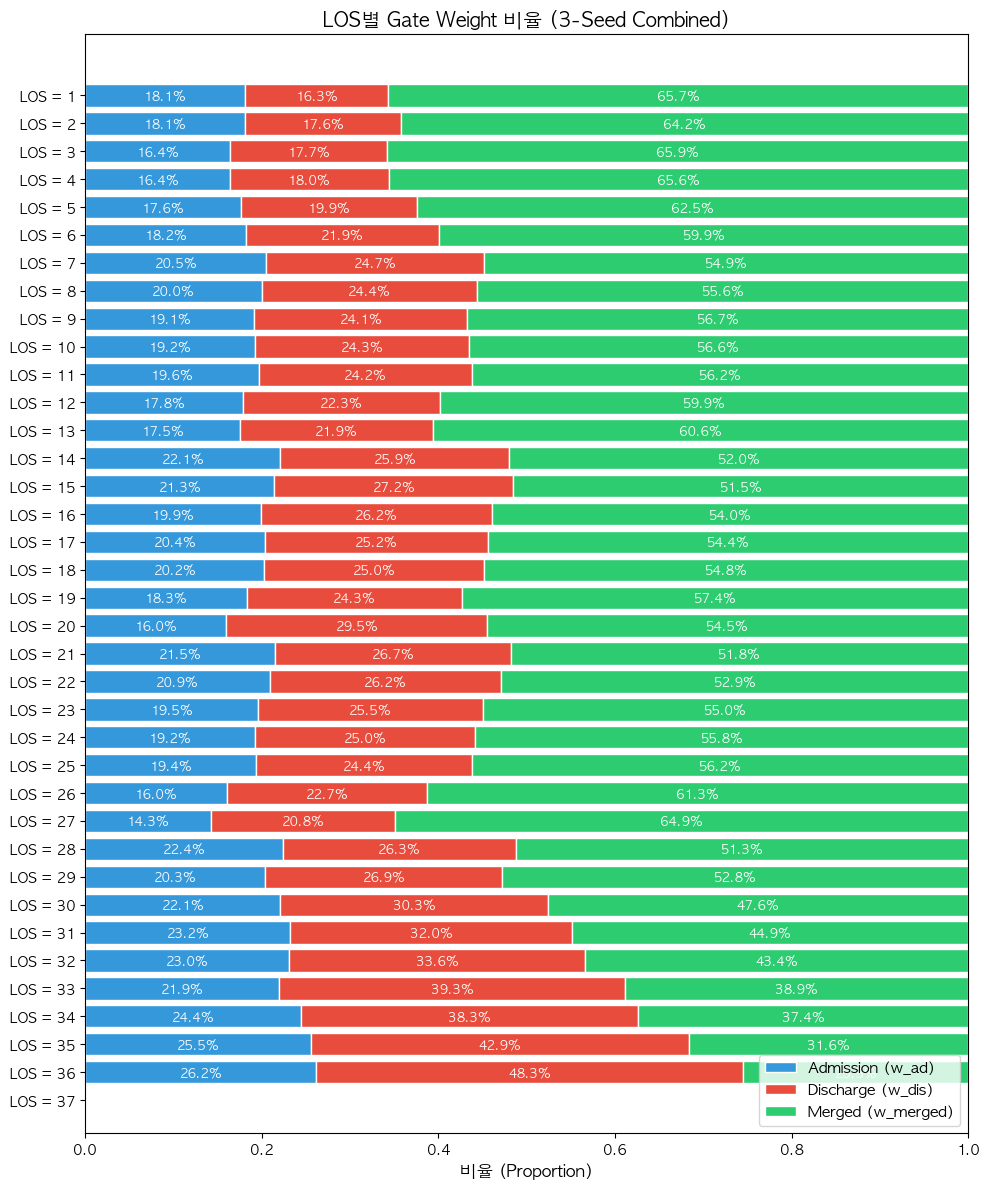

In [6]:
# 3 seed 평균을 비율로 정규화
means = pd.DataFrame({
    comp: combined[f'{comp}_mean_across']
    for comp in COMPONENTS
}, index=combined['LOS'])

proportions = means.div(means.sum(axis=1), axis=0)
los_labels  = [f'LOS = {v}' for v in proportions.index]

fig, ax = plt.subplots(figsize=(10, 12))

left = np.zeros(len(proportions))
for comp, color, label in zip(COMPONENTS, COMP_COLORS, COMP_LABELS):
    values = proportions[comp].values
    bars = ax.barh(los_labels, values, left=left, color=color, label=label, edgecolor='white')
    for bar, val, l in zip(bars, values, left):
        if val > 0.05:
            ax.text(l + val / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    left += values

ax.set_xlabel('비율 (Proportion)', fontsize=12)
ax.set_title('LOS별 Gate Weight 비율 (3-Seed Combined)', fontsize=14)
ax.set_xlim(0, 1)
ax.legend(loc='lower right', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('gated_fusion_weight_proportion_by_los.png', dpi=150, bbox_inches='tight')
plt.show()
